In [1]:
import pickle

In [2]:
with open("final_logistic_model.pkl", "rb") as f:
    model = pickle.load(f)

print("Model loaded successfully!")

Model loaded successfully!


# Loading data for SHAP background

In [3]:
import pandas as pd
import numpy as np
import shap
import matplotlib.pyplot as plt

In [4]:
df = pd.read_csv("cleaned_data.csv")

# Create the SHAP background data

In [5]:
# LogIncome
df['LogIncome'] = np.log(df['MonthlyIncome'])

# AgeGroup
bins = [19, 35, 50, 65, float('inf')]
labels = ['Young', 'Middle-aged', 'Senior', 'Old']

df['AgeGroup'] = pd.cut(df['age'],bins=bins,labels=labels)

# Select the exact features for SHAP

In [6]:
features = ['age','RevolvingUtilizationOfUnsecuredLines','NumberOfTime30-59DaysPastDueNotWorse',
            'NumberOfTime60-89DaysPastDueNotWorse','NumberOfTimes90DaysLate','DebtRatio','DebtRatioMissing',
            'NumberOfOpenCreditLinesAndLoans','NumberRealEstateLoansOrLines','NumberOfDependents','LogIncome','AgeGroup']

X_background = df[features].copy()

# Extract the preprocessing and Logistic Regression model

In [7]:
# Get the preprocessing part of the pipeline
preprocessor = model.named_steps['Preprocessing']

# Get the Logistic Regression model
logistic_model = model.named_steps['Logistic Model']

# Transform the background data

In [8]:
X_background_transformed = preprocessor.transform(X_background)

# Get the transformed feature names

In [9]:
feature_names = preprocessor.get_feature_names_out()

feature_names = np.array([name.split("__", 1)[-1]for name in feature_names])

print(feature_names)

['age' 'RevolvingUtilizationOfUnsecuredLines' 'LogIncome'
 'NumberOfOpenCreditLinesAndLoans' 'DebtRatio'
 'NumberOfTime30-59DaysPastDueNotWorse'
 'NumberOfTime60-89DaysPastDueNotWorse' 'NumberOfTimes90DaysLate'
 'NumberRealEstateLoansOrLines' 'NumberOfDependents' 'AgeGroup_Old'
 'AgeGroup_Senior' 'AgeGroup_Young' 'DebtRatioMissing']


# Create the customer's raw input

In [10]:
user_input = {'age': 40,'MonthlyIncome': 1000,'RevolvingUtilizationOfUnsecuredLines': 0.164673,
              'NumberOfTime30-59DaysPastDueNotWorse': 0,'NumberOfTime60-89DaysPastDueNotWorse': 0,'NumberOfTimes90DaysLate': 0,
              'DebtRatio': 1.482965,'NumberOfOpenCreditLinesAndLoans': 9,'NumberRealEstateLoansOrLines': 0,'NumberOfDependents': 2}

sample = pd.DataFrame([user_input])
sample['DebtRatioMissing'] = sample['DebtRatio'].isna().astype(int)
sample

,age,MonthlyIncome,RevolvingUtilizationOfUnsecuredLines,NumberOfTime30-59DaysPastDueNotWorse,NumberOfTime60-89DaysPastDueNotWorse,NumberOfTimes90DaysLate,DebtRatio,NumberOfOpenCreditLinesAndLoans,NumberRealEstateLoansOrLines,NumberOfDependents,DebtRatioMissing
0,40,1000,0.164673,0,0,0,1.482965,9,0,2,0


# Creating the two engineered features

In [11]:
# Create LogIncome
sample['LogIncome'] = np.log(sample['MonthlyIncome'])

# Create AgeGroup
sample['AgeGroup'] = pd.cut(sample['age'],bins=bins,labels=labels)

sample

,age,MonthlyIncome,RevolvingUtilizationOfUnsecuredLines,NumberOfTime30-59DaysPastDueNotWorse,NumberOfTime60-89DaysPastDueNotWorse,NumberOfTimes90DaysLate,DebtRatio,NumberOfOpenCreditLinesAndLoans,NumberRealEstateLoansOrLines,NumberOfDependents,DebtRatioMissing,LogIncome,AgeGroup
0,40,1000,0.164673,0,0,0,1.482965,9,0,2,0,6.907755,Middle-aged


# Select the exact columns for the saved model

In [12]:
features = ['age','RevolvingUtilizationOfUnsecuredLines','NumberOfTime30-59DaysPastDueNotWorse',
            'NumberOfTime60-89DaysPastDueNotWorse','NumberOfTimes90DaysLate','DebtRatio','DebtRatioMissing',
            'NumberOfOpenCreditLinesAndLoans','NumberRealEstateLoansOrLines','NumberOfDependents','LogIncome','AgeGroup']

sample = sample[features]

sample

,age,RevolvingUtilizationOfUnsecuredLines,NumberOfTime30-59DaysPastDueNotWorse,NumberOfTime60-89DaysPastDueNotWorse,NumberOfTimes90DaysLate,DebtRatio,DebtRatioMissing,NumberOfOpenCreditLinesAndLoans,NumberRealEstateLoansOrLines,NumberOfDependents,LogIncome,AgeGroup
0,40,0.164673,0,0,0,1.482965,0,9,0,2,6.907755,Middle-aged


# Transform the customer's data

In [13]:
sample_transformed = preprocessor.transform(sample)

# Create the SHAP explainer

In [14]:
explainer = shap.Explainer(logistic_model,X_background_transformed,feature_names=feature_names)

# Calculate the SHAP values

In [15]:
shap_values = explainer(sample_transformed)

# Generate the SHAP waterfall plot

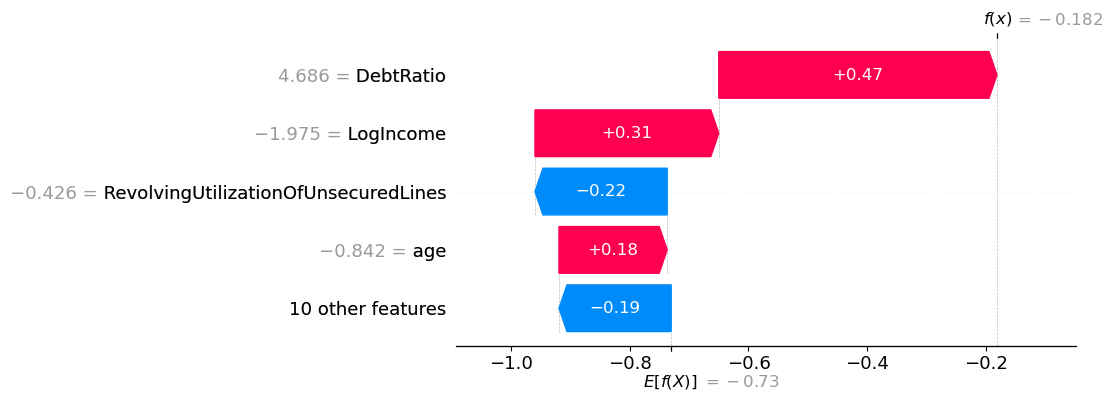

In [16]:
shap.plots.waterfall(shap_values[0],max_display=5)

plt.show()

# Probability of credit risk

In [17]:
probability = model.predict_proba(sample)[0, 1]

print(f"Credit Risk Probability: {probability:.2%}")

Credit Risk Probability: 45.47%


# Input-2

In [18]:
user_input = {'age': 40,'MonthlyIncome': 13700,'RevolvingUtilizationOfUnsecuredLines': 0.964673,'NumberOfTime30-59DaysPastDueNotWorse': 3,
              'NumberOfTime60-89DaysPastDueNotWorse': 1,'NumberOfTimes90DaysLate': 3,'DebtRatio': 0.382965,
              'NumberOfOpenCreditLinesAndLoans': 9,'NumberRealEstateLoansOrLines': 1,'NumberOfDependents': 2}

sample = pd.DataFrame([user_input])

# Automatically create DebtRatioMissing
sample['DebtRatioMissing'] = 0

sample

,age,MonthlyIncome,RevolvingUtilizationOfUnsecuredLines,NumberOfTime30-59DaysPastDueNotWorse,NumberOfTime60-89DaysPastDueNotWorse,NumberOfTimes90DaysLate,DebtRatio,NumberOfOpenCreditLinesAndLoans,NumberRealEstateLoansOrLines,NumberOfDependents,DebtRatioMissing
0,40,13700,0.964673,3,1,3,0.382965,9,1,2,0


In [19]:
# Create LogIncome
sample['LogIncome'] = np.log(sample['MonthlyIncome'])

# Create AgeGroup
sample['AgeGroup'] = pd.cut(sample['age'],bins=bins,labels=labels)

In [20]:
features = ['age','RevolvingUtilizationOfUnsecuredLines','NumberOfTime30-59DaysPastDueNotWorse',
            'NumberOfTime60-89DaysPastDueNotWorse','NumberOfTimes90DaysLate','DebtRatio','DebtRatioMissing',
            'NumberOfOpenCreditLinesAndLoans','NumberRealEstateLoansOrLines','NumberOfDependents','LogIncome','AgeGroup']

sample = sample[features]

sample

,age,RevolvingUtilizationOfUnsecuredLines,NumberOfTime30-59DaysPastDueNotWorse,NumberOfTime60-89DaysPastDueNotWorse,NumberOfTimes90DaysLate,DebtRatio,DebtRatioMissing,NumberOfOpenCreditLinesAndLoans,NumberRealEstateLoansOrLines,NumberOfDependents,LogIncome,AgeGroup
0,40,0.964673,3,1,3,0.382965,0,9,1,2,9.525151,Middle-aged


In [21]:
sample_transformed = preprocessor.transform(sample)

In [22]:
explainer = shap.Explainer(logistic_model,X_background_transformed,feature_names=feature_names)

In [23]:
shap_values = explainer(sample_transformed)

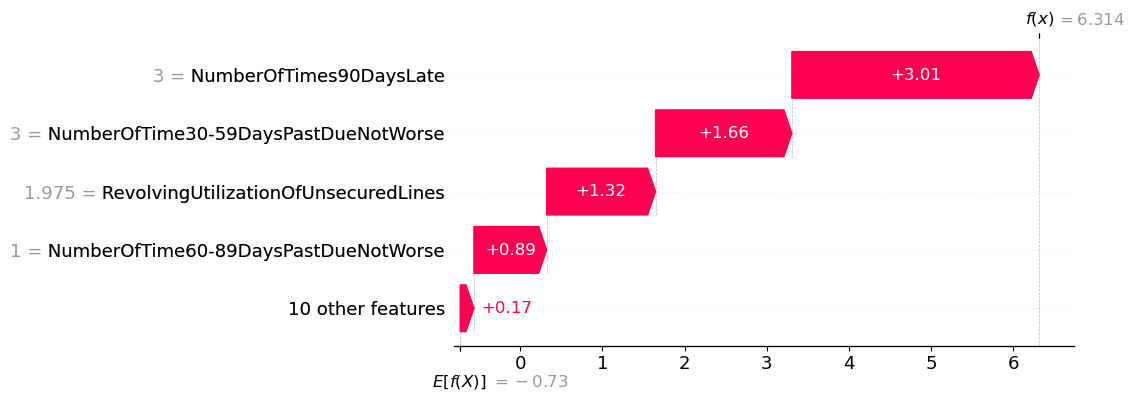

In [24]:
shap.plots.waterfall(shap_values[0],max_display=5)

plt.show()

In [25]:
probability = model.predict_proba(sample)[0, 1]

print(f"Credit Risk Probability: {probability:.2%}")

Credit Risk Probability: 99.82%
